In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import os

# 0. Inputs

In [24]:
# Class to store the output naming and locations
class Graph:
    def __init__(self, input_dir, test_type, load_type, channel):
        self.input_dir = input_dir
        self.csv_path = os.path.join(input_dir, load_type, "digital.csv")
        self.test_type = test_type
        self.load_type = load_type
        self.channel = channel
        self.jitter_title = "Jitter Distribution (" + test_type + " under " + load_type + ", Channel " + str(channel) + ")"
        self.jitter_file_name = "jitter_histogram_" + test_type + "_" + load_type + "_" + str(channel) + ".png"
        self.jitter_file_path = os.path.join(input_dir, self.jitter_file_name)

In [25]:
# Arguments. Test purpose only
input_dir = "/mnt/nvme0n1p5/Work/Projects/rt-kernel/local/test_results/default_2026-05-07-17-00-29"
test_type = "default"
channels = ["0", "1"]
nominal_period = 1.0
duration = 60.0

# Create array of data to use in the loop
graphs = [
    [Graph(input_dir, test_type, state, channel) for channel in channels]
    for state in ["idle", "load"]
]

# 1. Jitter

In [26]:
def load_csv_data(csv_path):
    """
    Loads period data from a Saleae CSV, calculates jitter,
    and returns key statistics.
    """
    try:
        # Saleae period exports have one column, usually named 'Time [s]' or the measurement name
        df = pd.read_csv(csv_path)
        # We rename the column for consistency, assuming it's the first one.
        if df.empty:
            print(f"Warning: CSV file '{csv_path}' is empty. Skipping analysis.")
            return None, None
        df.rename(columns={df.columns[0]: 'period_s'}, inplace=True)
    except FileNotFoundError:
        print(f"Error: The file '{csv_path}' was not found.")
        return None

    # Print the column names
    print(df.columns.tolist())
    columns = df.columns.tolist()

    return df, columns

def analyze_jitter(df, time_col, channel_col, nominal_period):
    # Calculate jitter in microseconds (µs)
    # Jitter = (Measured Period - Nominal Period)
    # df['jitter_us'] = (df['period_s'] - nominal_period) * 1_000_000
    # Identify 'Channel 0' toggles
    # toggles = df[df[channel_col].diff() != 0].copy()
    toggles = df[(df[channel_col] == 1) & (df[channel_col].shift(1) == 0)].copy()
    # Calculte the time between toggles (intervals)
    toggles['interval'] = (toggles[time_col].diff() - nominal_period) * 1_000_000
    # Remove the first NaN values
    intervals = toggles['interval'].dropna()

    # Calculate key statistics
    stats = {
        # 'mean_jitter_us': df['jitter_us'].mean(),
        # 'std_dev_us': df['jitter_us'].std(),
        # 'max_jitter_us': df['jitter_us'].max(),
        # 'min_jitter_us': df['jitter_us'].min(),
        # 'peak_to_peak_jitter_us': df['jitter_us'].max() - df['jitter_us'].min(),
        # 'sample_count': len(df)
        'mean_jitter_us': intervals.mean(),
        'std_dev_us': intervals.std(),
        'max_jitter_us': intervals.max(),
        'min_jitter_us': intervals.min(),
        'peak_to_peak_jitter_us': intervals.max() - intervals.min(),
        'sample_count': len(df)
    }

    # return df['jitter_us'], stats
    return intervals, stats

def plot_histogram(jitter_data, stats, title, output_file):
    """
    Generates and saves a histogram of the jitter data.
    """
    plt.style.use('ggplot')
    fig, ax = plt.subplots(figsize=(12, 7))

    # Create the histogram
    # The number of bins can be adjusted. 'auto' is a good starting point.
    ax.hist(jitter_data, bins='auto', density=True, alpha=0.75, label='Jitter Distribution')

    # Add a vertical line for the mean
    ax.axvline(stats['mean_jitter_us'], color='r', linestyle='--', linewidth=2, label=f"Mean: {stats['mean_jitter_us']:.2f} µs")

    # --- Formatting the Plot ---
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Jitter (µs) from Nominal Period', fontsize=12)
    ax.set_ylabel('Probability Density', fontsize=12)
    ax.grid(True)
    ax.legend()

    # Add a text box with detailed statistics
    stats_text = (
        f"Samples: {stats['sample_count']}\n"
        f"Std Dev: {stats['std_dev_us']:.2f} µs\n"
        f"Min Jitter: {stats['min_jitter_us']:.2f} µs\n"
        f"Max Jitter (WCET): {stats['max_jitter_us']:.2f} µs\n"
        f"Peak-to-Peak: {stats['peak_to_peak_jitter_us']:.2f} µs"
    )
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)

    plt.show()
    # Save the figure to a file
    # plt.savefig(output_file, dpi=300, bbox_inches='tight')
    # plt.close(fig) # Close the figure to free up memory
    print(f"Histogram saved to '{output_file}'")

['period_s', 'Channel 0', 'Channel 1']
Successfully matched graph channel 0 to column 'Channel 0'

--- Jitter Analysis Results for  idle  Test---
Mean Jitter Us: 404.81
Std Dev Us: 62.76
Max Jitter Us: 694.12
Min Jitter Us: 298.50
Peak To Peak Jitter Us: 395.62
Sample Count: 242.00
-----------------------------



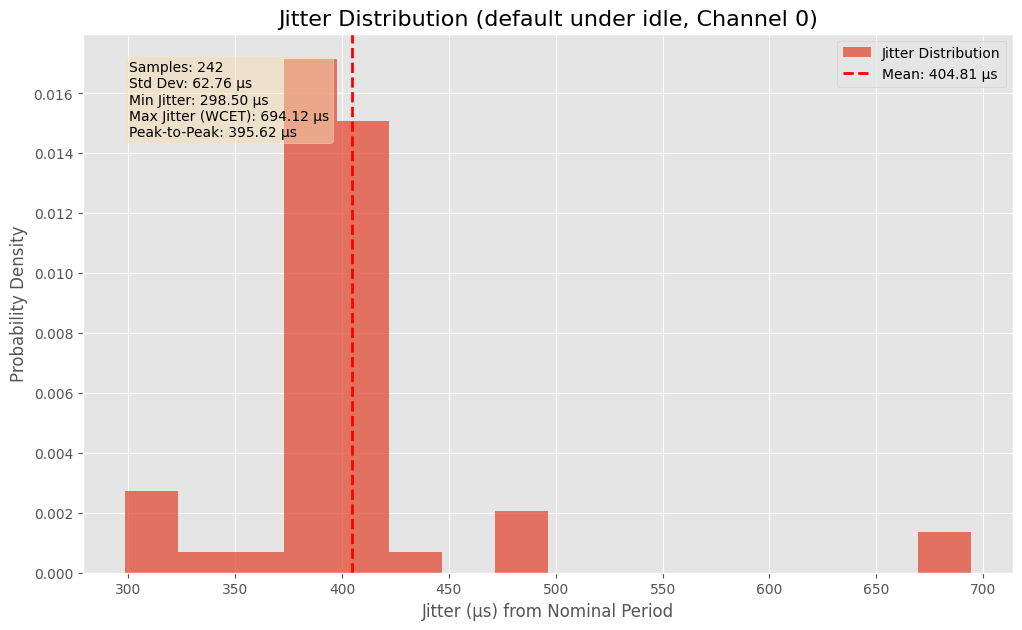

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local/test_results/default_2026-05-07-17-00-29/jitter_histogram_default_idle_0.png'
Successfully matched graph channel 1 to column 'Channel 1'

--- Jitter Analysis Results for  idle  Test---
Mean Jitter Us: 70.09
Std Dev Us: 0.06
Max Jitter Us: 70.13
Min Jitter Us: 70.00
Peak To Peak Jitter Us: 0.13
Sample Count: 242.00
-----------------------------



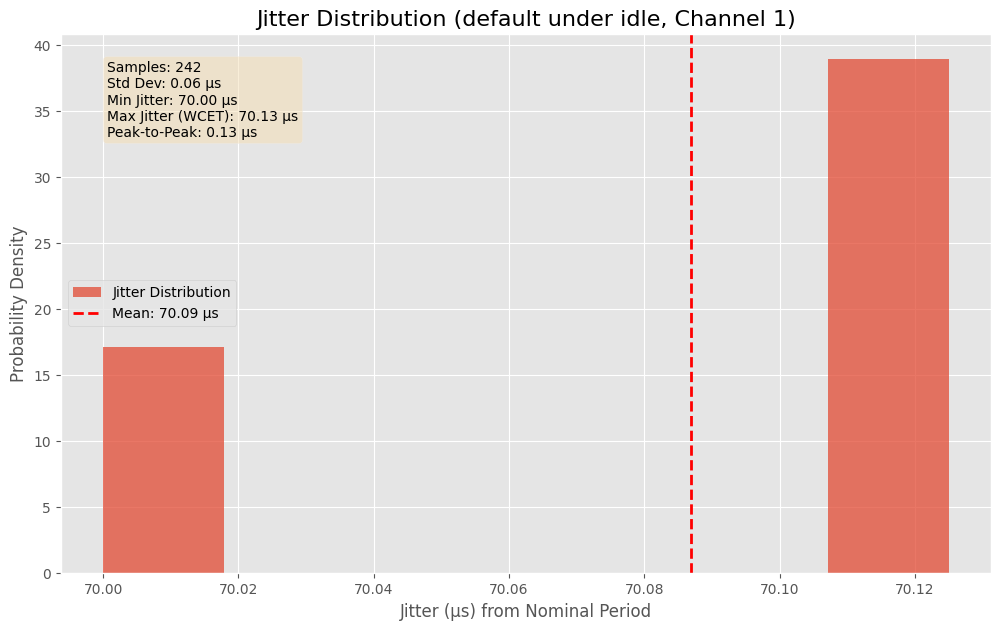

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local/test_results/default_2026-05-07-17-00-29/jitter_histogram_default_idle_1.png'
['period_s', 'Channel 0', 'Channel 1']
Successfully matched graph channel 0 to column 'Channel 0'

--- Jitter Analysis Results for  load  Test---
Mean Jitter Us: 403.79
Std Dev Us: 81.34
Max Jitter Us: 851.75
Min Jitter Us: 312.00
Peak To Peak Jitter Us: 539.75
Sample Count: 242.00
-----------------------------



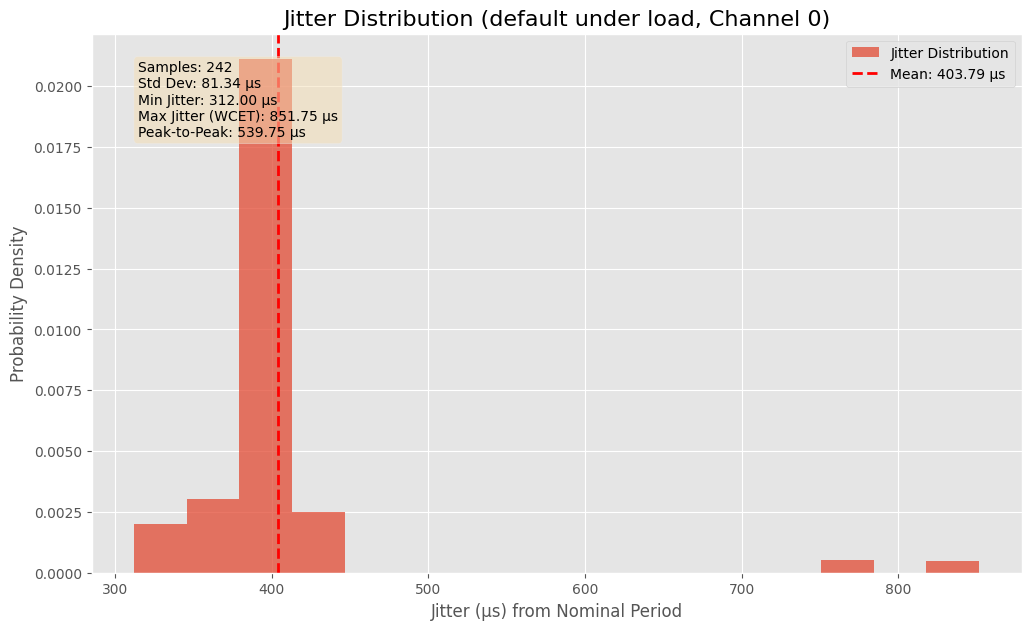

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local/test_results/default_2026-05-07-17-00-29/jitter_histogram_default_load_0.png'
Successfully matched graph channel 1 to column 'Channel 1'

--- Jitter Analysis Results for  load  Test---
Mean Jitter Us: 70.09
Std Dev Us: 0.06
Max Jitter Us: 70.13
Min Jitter Us: 70.00
Peak To Peak Jitter Us: 0.13
Sample Count: 242.00
-----------------------------



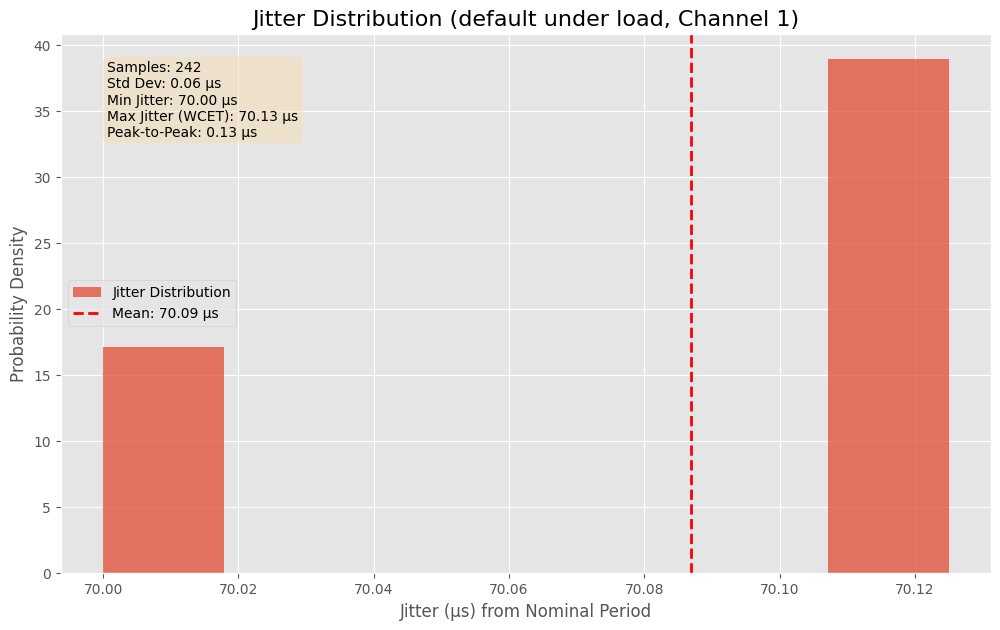

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local/test_results/default_2026-05-07-17-00-29/jitter_histogram_default_load_1.png'


In [27]:
# --- Data Analysis ---
for state_graphs in graphs:
    df, columns = load_csv_data(state_graphs[0].csv_path)
    time_col = columns[0]

    # Make sure that there are real data
    if df is None:
        print("Error: No data available at path " + state_graphs[0].csv_path + ". Skipping analysis.")
        continue

    # Iterate through graph object on each channel
    for graph in state_graphs:
        # Regex patern to match column name
        pattern = rf"Channel\s*{graph.channel}\b"

        # Searc by the pattern
        matched_idx, matched_col = next(
            ((i, col) for i, col in enumerate(columns) if re.search(pattern, col, re.IGNORECASE)),
            (None, None)
        )

        # Check if a column was found
        if matched_idx is not None:
            print(f"Successfully matched graph channel {graph.channel} to column '{matched_col}'")
            jitter_values, statistics = analyze_jitter(df, time_col, matched_col, nominal_period)
            if jitter_values is not None:
                print("\n--- Jitter Analysis Results for ", graph.load_type, " Test---")
                for key, value in statistics.items():
                    print(f"{key.replace('_', ' ').title()}: {value:.2f}")
                print("-----------------------------\n")
                plot_histogram(jitter_values, statistics, graph.jitter_title, graph.jitter_file_path)
        else:
            print(f"Warning: No column found matching pattern '{pattern}'")

# 2. Jitter plus

In [28]:
csv_path_idle = input_dir + "/idle/digital.csv"
csv_path_load = input_dir + "/load/digital.csv"

def load_independent_csv_data(csv_path):
    try:
        # Saleae period exports have one column, usually named 'Time [s]' or the measurement name
        df = pd.read_csv(csv_path)
        # We rename the column for consistency, assuming it's the first one.
        if df.empty:
            print(f"Warning: CSV file '{csv_path}' is empty. Skipping analysis.")
            return None, None
        df.rename(columns={df.columns[0]: 'period_s'}, inplace=True)
    except FileNotFoundError:
        print(f"Error: The file '{csv_path}' was not found.")
        return None
    
    # Print the column names
    print(df.columns.tolist())
    columns = df.columns.tolist()
    
    return df, columns

# Print the column names
df_datas_idle, df_columns_idle = load_independent_csv_data(csv_path_idle)
df_datas_load, df_columns_load = load_independent_csv_data(csv_path_load)

['period_s', 'Channel 0', 'Channel 1']
['period_s', 'Channel 0', 'Channel 1']


In [29]:
def perform_timing_analysis(df, time_col, channel_col, nominal_period):
    """
    Calculates Jitter, Drift, Latency, and Phase based on a nominal period.
    """
    # Detect Edges (0 -> 1 transition) - rising
    # Detect Edges (1 -> 0 transition) - falling
    rising = df[(df[channel_col] == 1) & (df[channel_col].shift(1) == 0)][time_col].values
    falling = df[(df[channel_col] == 0) & (df[channel_col].shift(1) == 1)][time_col].values

    # Ensure alignment: Start with Rising, End with Falling
    if len(falling) > 0 and len(rising) > 0 and falling[0] < rising[0]: 
        falling = falling[1:]
        
    min_len = min(len(rising), len(falling))
    rising = rising[:min_len]
    falling = falling[:min_len]

    # 1. Rising Edge Metrics (N-1 samples)
    # Time axis for jitter is the time of the edge that "arrived" (rising[1:])
    periods_rise = np.diff(rising)
    time_jitter_rise = rising[1:] 
    jitter_rise = (periods_rise - nominal_period) * 1_000_000
    drift_rise = np.cumsum(jitter_rise)

    # 2. Falling Edge Metrics (N-1 samples)
    periods_fall = np.diff(falling)
    time_jitter_fall = falling[1:]
    jitter_fall = (periods_fall - nominal_period) * 1_000_000
    drift_fall = np.cumsum(jitter_fall)

    # 3. Pulse Metrics (N samples)
    # Time axis is the start of each pulse
    time_pulse = rising 
    pulse_widths = falling - rising
    duty_cycles = (pulse_widths / nominal_period) * 100

    return {
        # Time Axes
        'time_jitter_rise': time_jitter_rise,  # For jitter_rise and drift_rise
        'time_jitter_fall': time_jitter_fall,  # For jitter_fall and drift_fall
        'time_pulse': time_pulse,              # For duty_cycles and pulse_widths
        
        # Data Arrays
        'edges_rise': rising,
        'edges_fall': falling,
        'jitter_rise': jitter_rise,
        'jitter_fall': jitter_fall,
        'drifts_rise': drift_rise,
        'drifts_fall': drift_fall,
        'duty_cycles': duty_cycles,
        'pulse_widths': pulse_widths,
        
        # Metadata & Stats
        'channel': channel_col,
        'mean_jitter_rise_us': jitter_rise.mean() if len(jitter_rise) > 0 else 0,
        'std_dev_rise_us': jitter_rise.std() if len(jitter_rise) > 0 else 0,
        'max_jitter_rise_us': jitter_rise.max() if len(jitter_rise) > 0 else 0,
        'min_jitter_rise_us': jitter_rise.min() if len(jitter_rise) > 0 else 0,
        'peak_to_peak_jitter_rise_us': (jitter_rise.max() - jitter_rise.min()) if len(jitter_rise) > 0 else 0,
        'mean_jitter_fall_us': jitter_fall.mean() if len(jitter_fall) > 0 else 0,
        'std_dev_fall_us': jitter_fall.std() if len(jitter_fall) > 0 else 0,
        'max_jitter_fall_us': jitter_fall.max() if len(jitter_fall) > 0 else 0,
        'min_jitter_fall_us': jitter_fall.min() if len(jitter_fall) > 0 else 0,
        'peak_to_peak_jitter_fall_us': (jitter_fall.max() - jitter_fall.min()) if len(jitter_fall) > 0 else 0,
        'sample_count': len(df)
    }

def phase_shift(edges0, edges1, nominal_period):
    # Cross-Channel Calculations (Latency & Phase)
    # Ensure we compare the same number of pulses
    min_len = min(len(edges0), len(edges1))
    latency = edges1[:min_len] - edges0[:min_len]
    phase_diff = (latency / nominal_period) * 360

    return {
        'latency': latency,
        'phase': phase_diff,
        'time_axis': edges0[:min_len]
    }

In [30]:
# Calculate for idle
results_idle = [
    perform_timing_analysis(df_datas_idle, df_columns_idle[0], df_column_idle, nominal_period)
    for df_column_idle in [df_columns_idle[1], df_columns_idle[2]]
]

phase_idle = phase_shift(results_idle[0]['edges_rise'], results_idle[1]['edges_rise'], nominal_period)

# Calculate for load
results_load = [
    perform_timing_analysis(df_datas_load, df_columns_load[0], df_column_load, nominal_period)
    for df_column_load in [df_columns_load[1], df_columns_load[2]]
]

phase_load = phase_shift(results_load[0]['edges_rise'], results_load[1]['edges_rise'], nominal_period)

In [31]:

def plot_histogram_rise(jitter_data, stats, title, output_file):
    """
    Generates and saves a histogram of the jitter data.
    """
    plt.style.use('ggplot')
    fig, ax = plt.subplots(figsize=(12, 7))

    # Create the histogram
    # The number of bins can be adjusted. 'auto' is a good starting point.
    ax.hist(jitter_data, bins='auto', density=True, alpha=0.75, label='Jitter Distribution')

    # Add a vertical line for the mean
    ax.axvline(stats['mean_jitter_rise_us'], color='r', linestyle='--', linewidth=2, label=f"Mean: {stats['mean_jitter_rise_us']:.2f} µs")

    # --- Formatting the Plot ---
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Jitter (µs) from Nominal Period', fontsize=12)
    ax.set_ylabel('Probability Density', fontsize=12)
    ax.grid(True)
    ax.legend()

    # Add a text box with detailed statistics
    stats_text = (
        f"Samples: {stats['sample_count']}\n"
        f"Std Dev: {stats['std_dev_rise_us']:.2f} µs\n"
        f"Min Jitter: {stats['min_jitter_rise_us']:.2f} µs\n"
        f"Max Jitter (WCET): {stats['max_jitter_rise_us']:.2f} µs\n"
        f"Peak-to-Peak: {stats['peak_to_peak_jitter_rise_us']:.2f} µs"
    )
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)

    plt.show()
    # Save the figure to a file
    # plt.savefig(output_file, dpi=300, bbox_inches='tight')
    # plt.close(fig) # Close the figure to free up memory
    print(f"Histogram saved to '{output_file}'")


def plot_histogram_fall(jitter_data, stats, title, output_file):
    """
    Generates and saves a histogram of the jitter data.
    """
    plt.style.use('ggplot')
    fig, ax = plt.subplots(figsize=(12, 7))

    # Create the histogram
    # The number of bins can be adjusted. 'auto' is a good starting point.
    ax.hist(jitter_data, bins='auto', density=True, alpha=0.75, label='Jitter Distribution')

    # Add a vertical line for the mean
    ax.axvline(stats['mean_jitter_fall_us'], color='r', linestyle='--', linewidth=2, label=f"Mean: {stats['mean_jitter_fall_us']:.2f} µs")

    # --- Formatting the Plot ---
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Jitter (µs) from Nominal Period', fontsize=12)
    ax.set_ylabel('Probability Density', fontsize=12)
    ax.grid(True)
    ax.legend()

    # Add a text box with detailed statistics
    stats_text = (
        f"Samples: {stats['sample_count']}\n"
        f"Std Dev: {stats['std_dev_fall_us']:.2f} µs\n"
        f"Min Jitter: {stats['min_jitter_fall_us']:.2f} µs\n"
        f"Max Jitter (WCET): {stats['max_jitter_fall_us']:.2f} µs\n"
        f"Peak-to-Peak: {stats['peak_to_peak_jitter_fall_us']:.2f} µs"
    )
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)

    plt.show()
    # Save the figure to a file
    # plt.savefig(output_file, dpi=300, bbox_inches='tight')
    # plt.close(fig) # Close the figure to free up memory
    print(f"Histogram saved to '{output_file}'")

def plot_histogram_combined(stats, title, output_file):
    """
    Generates and saves a histogram of the jitter data.
    """
    plt.style.use('ggplot')
    fig, ax1 = plt.subplots(figsize=(12, 7))
    ax2 = ax1.twinx()

    # Create the histogram
    # The number of bins can be adjusted. 'auto' is a good starting point.
    ax1.hist(stats['jitter_rise'], bins='auto', density=True, color='r', alpha=0.75, label='Jitter Distribution Rise')
    ax2.hist(stats['jitter_fall'], bins='auto', density=True, color='b', alpha=0.45, label='Jitter Distribution Fall')

    # Add a vertical line for the mean
    ax1.axvline(stats['mean_jitter_rise_us'], color='r', linestyle='dashed', linewidth=2, label=f"Mean: {stats['mean_jitter_fall_us']:.2f} µs")
    ax2.axvline(stats['mean_jitter_fall_us'], color='b', linestyle='dotted', linewidth=2, label=f"Mean: {stats['mean_jitter_fall_us']:.2f} µs")

    # --- Formatting the Plot ---
    ax1.set_title(title, fontsize=16)
    ax1.set_xlabel('Jitter (µs) from Nominal Period', fontsize=12)
    ax1.set_ylabel('Probability Density', fontsize=12)
    ax1.grid(True)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2)

    # Add a text box with detailed statistics
    stats_rise_fall_text = (
        f"Samples: {stats['sample_count']}\n"
        f"Std Dev Rise: {stats['std_dev_rise_us']:.2f} µs\n"
        f"Std Dev Fall: {stats['std_dev_fall_us']:.2f} µs\n"
        f"Min Jitter Rise: {stats['min_jitter_rise_us']:.2f} µs\n"
        f"Min Jitter Fall: {stats['min_jitter_fall_us']:.2f} µs\n"
        f"Max Jitter Rise (WCET): {stats['max_jitter_rise_us']:.2f} µs\n"
        f"Max Jitter Fall (WCET): {stats['max_jitter_fall_us']:.2f} µs\n"
        f"Peak-to-Peak Rise: {stats['peak_to_peak_jitter_rise_us']:.2f} µs\n"
        f"Peak-to-Peak Fall: {stats['peak_to_peak_jitter_fall_us']:.2f} µs"
    )
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax1.text(0.02, 0.97, stats_rise_fall_text, transform=ax1.transAxes, fontsize=10,
            verticalalignment='top', bbox=props)

    plt.show()
    # Save the figure to a file
    # plt.savefig(output_file, dpi=300, bbox_inches='tight')
    # plt.close(fig) # Close the figure to free up memory
    print(f"Histogram saved to '{output_file}'")

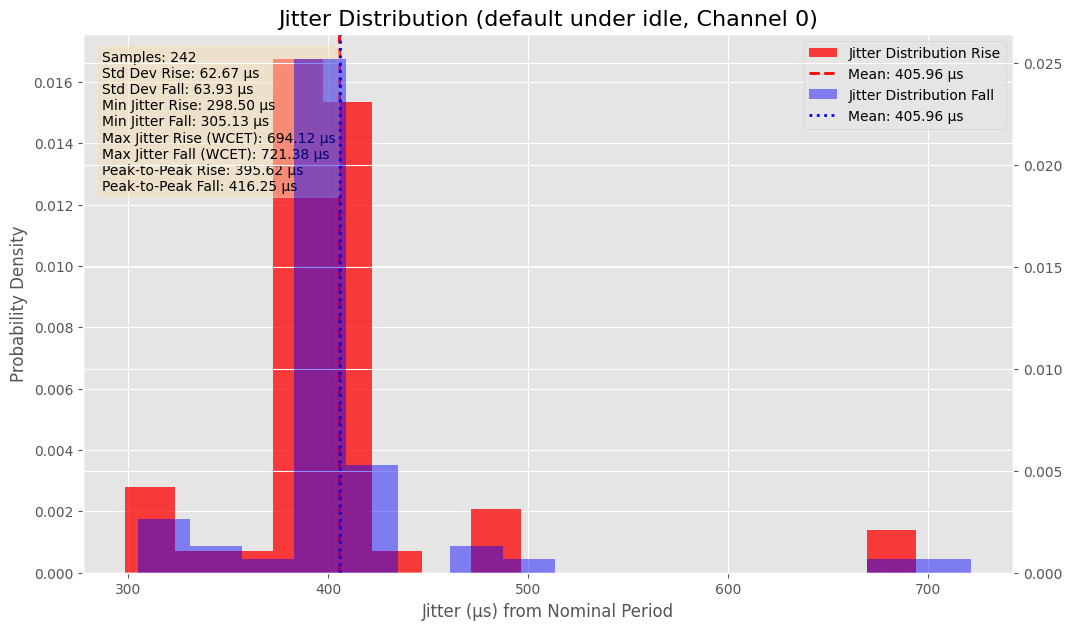

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local/test_results/default_2026-05-07-17-00-29/jitter_histogram_default_idle_0.png'


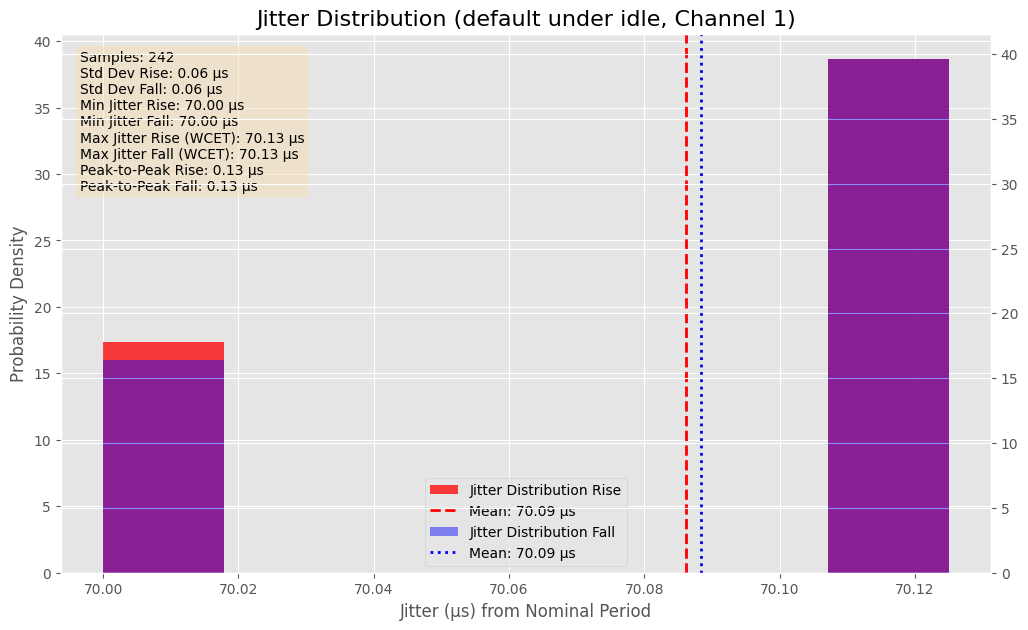

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local/test_results/default_2026-05-07-17-00-29/jitter_histogram_default_idle_1.png'


In [32]:
# Idle measurement
index = 0
for result in results_idle:
    # plot_histogram_rise(result['jitter_rise'], result, graphs[0][index].jitter_title, graphs[0][index].jitter_file_path)
    # plot_histogram_fall(result['jitter_fall'], result, graphs[0][index].jitter_title, graphs[0][index].jitter_file_path)
    plot_histogram_combined(result, graphs[0][index].jitter_title, graphs[0][index].jitter_file_path)
    index += 1

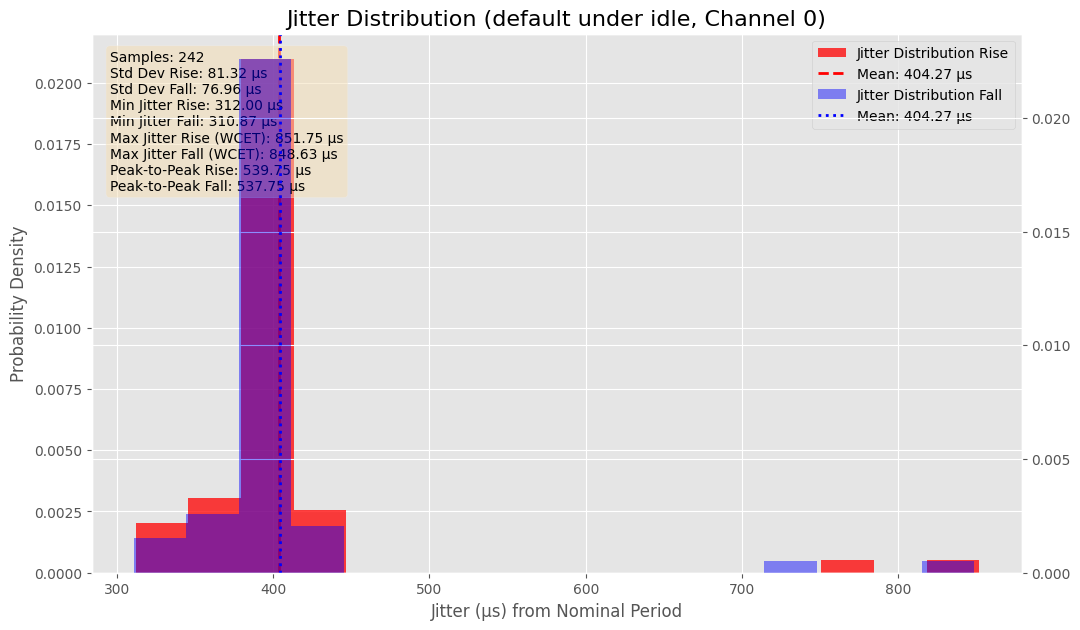

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local/test_results/default_2026-05-07-17-00-29/jitter_histogram_default_idle_0.png'


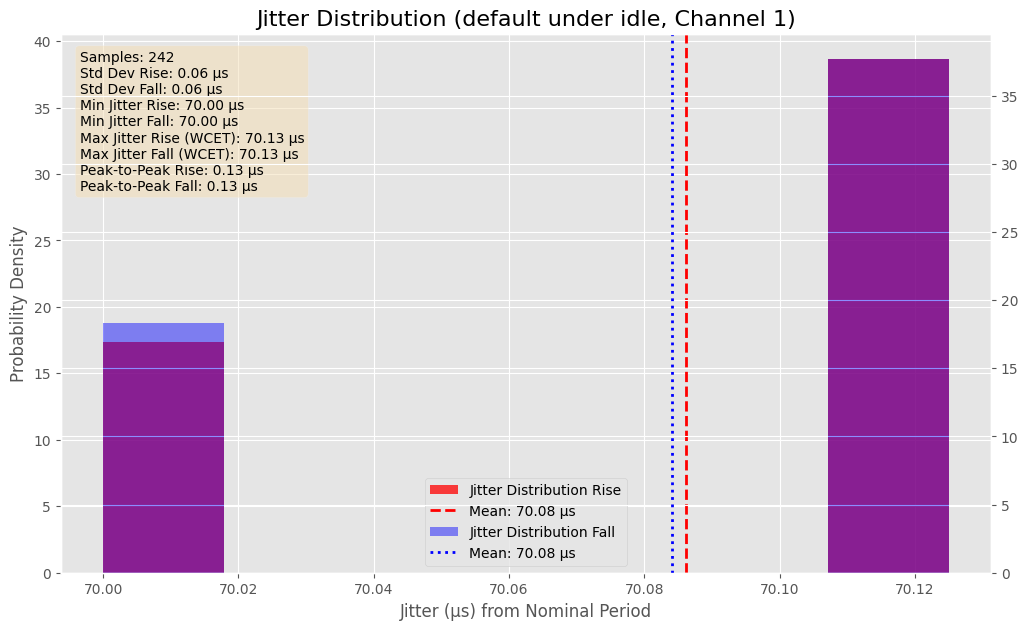

Histogram saved to '/mnt/nvme0n1p5/Work/Projects/rt-kernel/local/test_results/default_2026-05-07-17-00-29/jitter_histogram_default_idle_1.png'


In [33]:
# Load measurement
index = 0
for result in results_load:
    plot_histogram_combined(result, graphs[0][index].jitter_title, graphs[0][index].jitter_file_path)
    index += 1

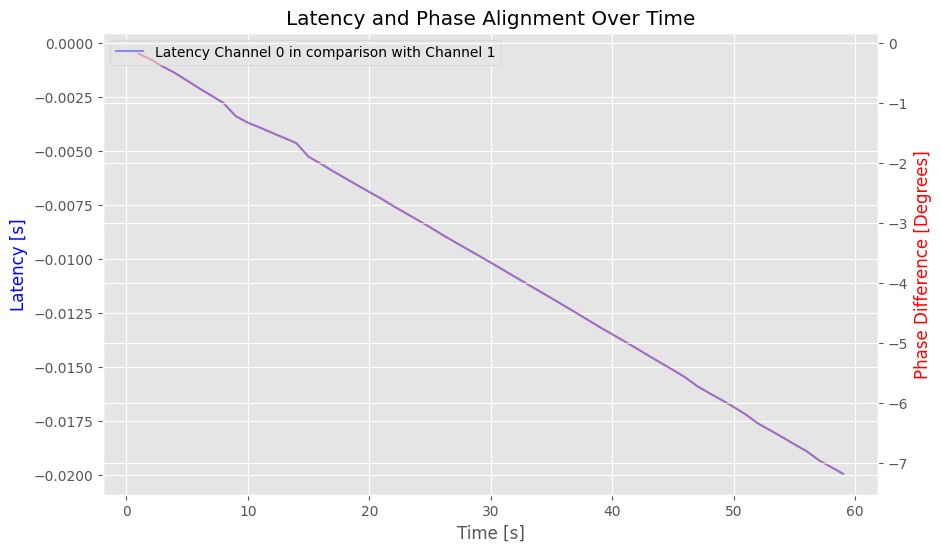

In [34]:
# 2. Latency & Phase Over Time
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()
# for phase in phase_idle.values():
ax1.plot(phase_idle['time_axis'], phase_idle['latency'], alpha=0.4, color='blue', label=f"Latency {results_idle[0]['channel']} in comparison with {results_idle[1]['channel']}")
ax2.plot(phase_idle['time_axis'], phase_idle['phase'], alpha=0.2, color='red') # Just to sync scales if needed

ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Latency [s]', color='blue')
ax2.set_ylabel('Phase Difference [Degrees]', color='red')
plt.title('Latency and Phase Alignment Over Time')
ax1.legend(loc='upper left')
plt.savefig('final_latency_phase.png')

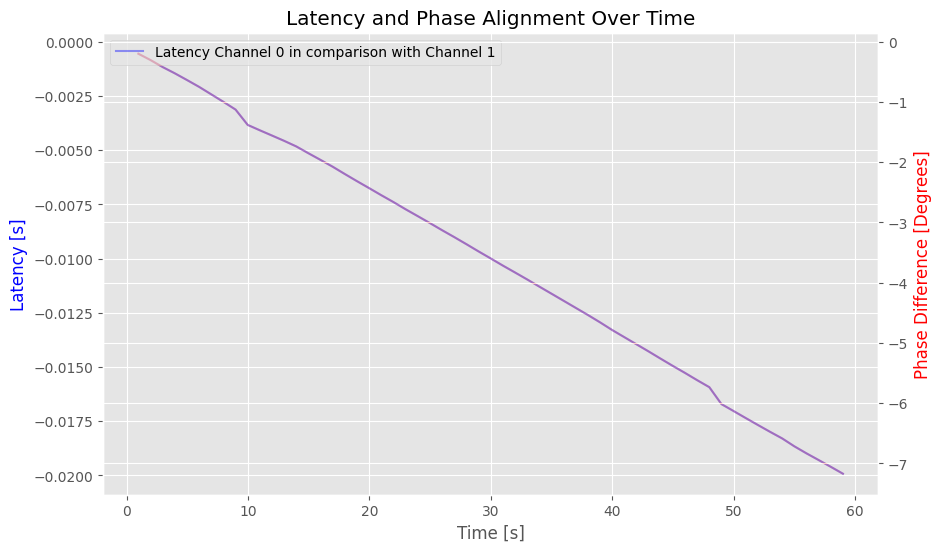

In [35]:
# 2. Latency & Phase Over Time
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()
# for phase in phase_idle.values():
ax1.plot(phase_load['time_axis'], phase_load['latency'], alpha=0.4, color='blue', label=f"Latency {results_load[0]['channel']} in comparison with {results_load[1]['channel']}")
ax2.plot(phase_load['time_axis'], phase_load['phase'], alpha=0.2, color='red') # Just to sync scales if needed

ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Latency [s]', color='blue')
ax2.set_ylabel('Phase Difference [Degrees]', color='red')
plt.title('Latency and Phase Alignment Over Time')
ax1.legend(loc='upper left')
plt.savefig('final_latency_phase.png')

In [47]:
def plot_duty_cycle_combined(stats_idle, stats_load, title, output_file, y_lim=None):
    """
    Generates and saves a histogram of the jitter data.
    """
    plt.style.use('ggplot')
    fig, ax = plt.subplots(figsize=(12, 7))

    # Create the plot
    # The number of bins can be adjusted. 'auto' is a good starting point.
    ax.plot(stats_idle['time_pulse'], stats_idle['duty_cycles'], marker='.', linestyle='dashed', color='r', alpha=0.75, label='Duty Cycle Idle')
    ax.plot(stats_load['time_pulse'], stats_load['duty_cycles'], marker='.', linestyle='dotted', color='b', alpha=0.45, label='Duty Cycle Load')

    # Add a vertical line for the mean
    ax.axhline(50, color='black', linestyle='dashed', linewidth=1, alpha=0.3, label=f"Target (50%)")

    # --- Formatting the Plot ---
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Time [s]', fontsize=12)
    ax.set_ylabel('Duryt Cycle (%)', fontsize=12)
    ax.grid(True)
    ax.legend(loc='best')

    # --- SET Y AXIS RANGE ---
    # ax.set_ylim(50)
    # Change this in your plotting function to see the tiny fluctuations
    ax.set_ylim(y_lim)

    plt.tight_layout()
    plt.show()
    # Save the figure to a file
    # plt.savefig(output_file, dpi=300, bbox_inches='tight')
    # plt.close(fig) # Close the figure to free up memory
    print(f"Histogram saved to '{output_file}'")

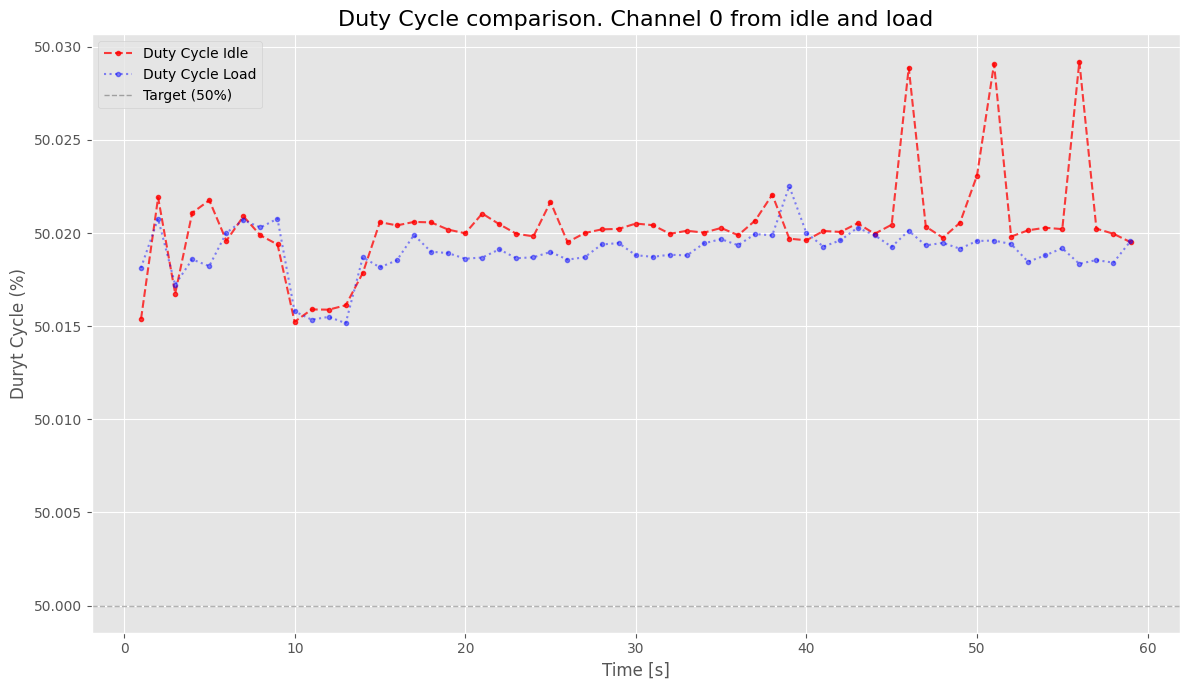

Histogram saved to 'duty_cycle_idle_load_0.png'


In [48]:
plot_duty_cycle_combined(results_idle[0], results_load[0], "Duty Cycle comparison. Channel 0 from idle and load", "duty_cycle_idle_load_0.png")

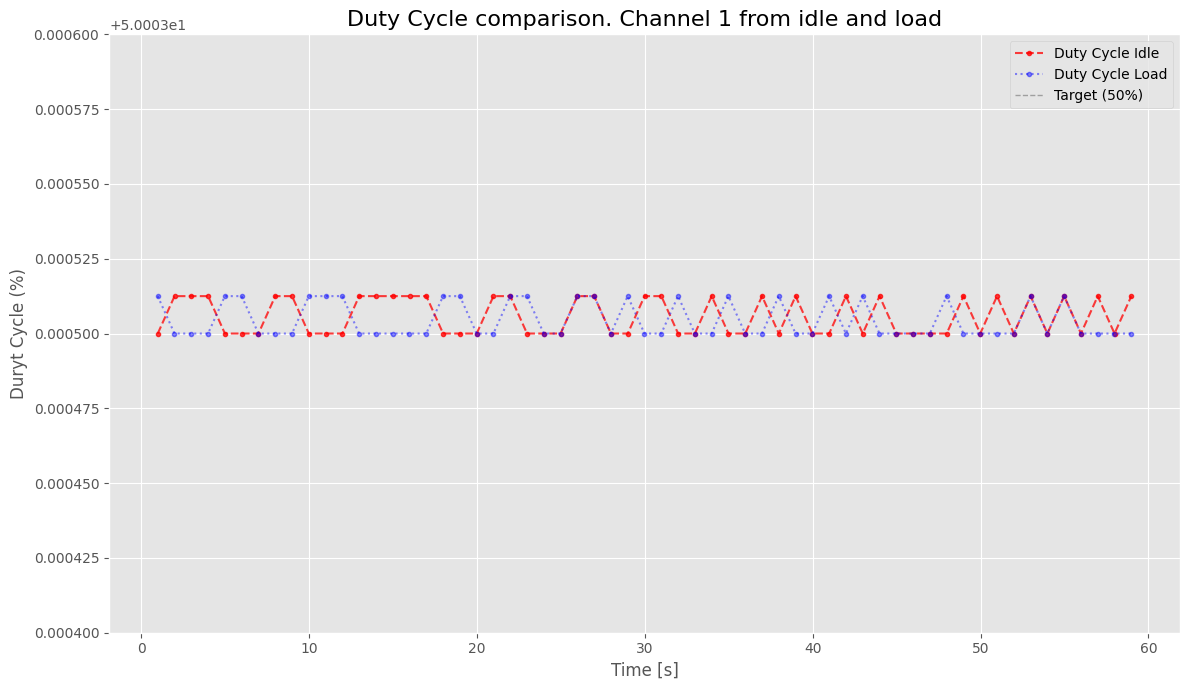

Histogram saved to 'duty_cycle_idle_load_1.png'


In [49]:
plot_duty_cycle_combined(results_idle[1], results_load[1], "Duty Cycle comparison. Channel 1 from idle and load", "duty_cycle_idle_load_1.png", y_lim=(50.0034, 50.0036))